<a href="https://colab.research.google.com/github/Ramjeet-Dixit/IITM-AIML-Rdixit/blob/main/Copy_of_CNN_for_Cats_and_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dogs vs Cats CNN Case Study

## Objective
The objective of this case study is to develop a **Convolutional Neural Network (CNN)** that can automatically classify images into two categories: **dogs** and **cats**. The focus is on demonstrating how CNNs can learn visual patterns and features to differentiate between the two classes, while ensuring good performance on unseen data.

---

## Data Description
The dataset consists of labeled images belonging to two categories: **dogs** and **cats**.  
- The images are in color (RGB) format.  
- They vary in resolution and are typically resized to a uniform dimension (e.g., 150×150 or 224×224) before being used for training.  
- The dataset includes diverse examples with variations in lighting, backgrounds, breeds, and poses.  

This diversity makes it a strong candidate for testing the ability of CNN models to generalize in real-world classification tasks.


In [1]:
# Unzip dataset
import shutil
shutil.unpack_archive("dataset.zip")

ReadError: dataset.zip is not a zip file

In [ ]:
# Load the data
from tensorflow.keras.utils import image_dataset_from_directory
train_dir = "dataset/training_set"
test_dir = "dataset/test_set"

train_ds = image_dataset_from_directory(train_dir,batch_size=32,
                                        image_size=(150, 150),shuffle=True,
                                       label_mode="binary")

test_ds = image_dataset_from_directory(test_dir,batch_size=32,
                                        image_size=(150, 150),label_mode="binary")


Found 8000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
!pip install livelossplot

In [ ]:
# Import Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Rescaling
from livelossplot import PlotLossesKerasTF

In [ ]:
# Define the CNN architecture
model = Sequential()
model.add(Input(shape=(150,150,3))) # Input Layer
model.add(Rescaling(1/255))#normalisation
model.add(Conv2D(32, (3,3), activation ='relu')) # First convolutional layer
model.add(MaxPooling2D()) # First Pooling Layer- default filter size is 2 by 2

model.add(Conv2D(64, (3,3), activation ='relu')) # Second convolutional layer
model.add(MaxPooling2D()) # Second Pooling Layer- default filter size is 2 by 2

model.add(Conv2D(128, (3,3), activation ='relu')) # Third convolutional layer
model.add(MaxPooling2D()) # Third Pooling Layer- default filter size is 2 by 2


model.add(Flatten()) # Flatten layer

model.add(Dense(100,activation='relu')) # FC Layer
model.add(Dense(1,activation='sigmoid')) #output layer

In [ ]:
# Compile the model
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │     3,699,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,792,649 (14.47 MB)

 Trainable params: 3,792,649 (14.47 MB)

 Non-trainable params: 0 (0.00 B)

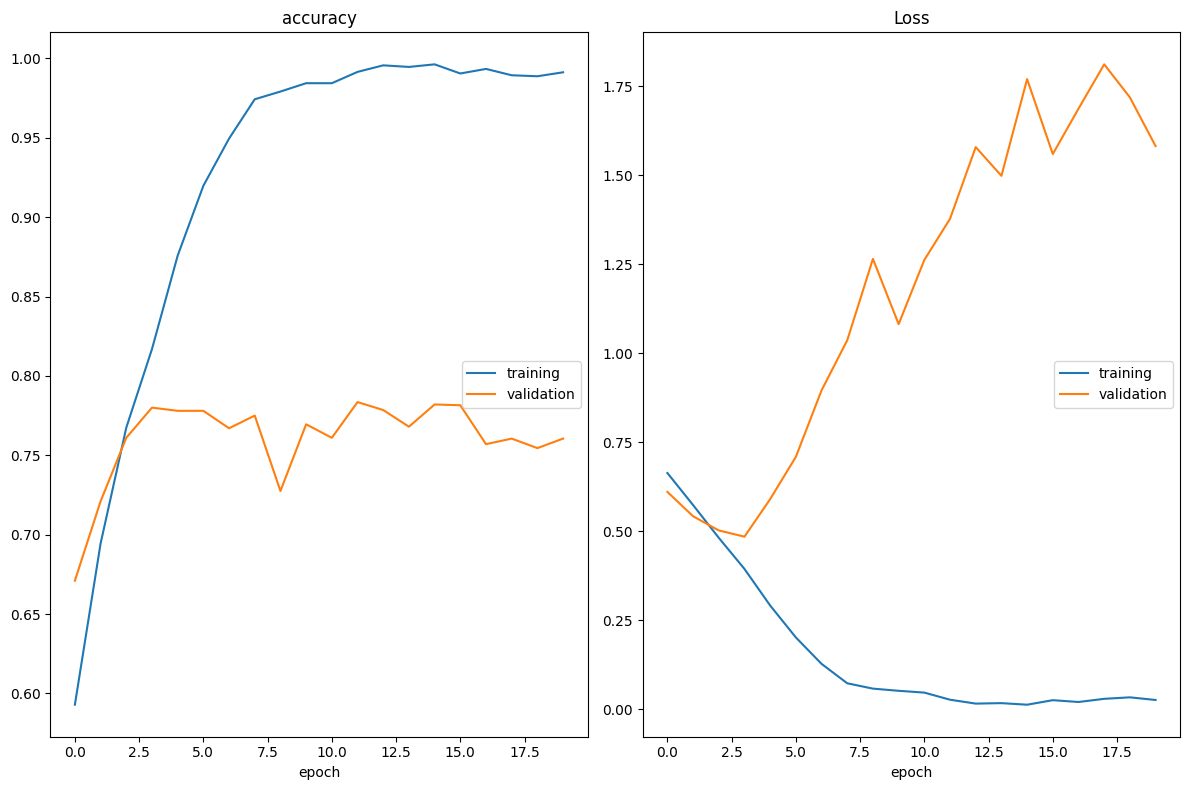

accuracy
	training         	 (min:    0.593, max:    0.996, cur:    0.991)
	validation       	 (min:    0.671, max:    0.784, cur:    0.761)
Loss
	training         	 (min:    0.013, max:    0.664, cur:    0.026)
	validation       	 (min:    0.485, max:    1.812, cur:    1.582)
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9908 - loss: 0.0247 - val_accuracy: 0.7605 - val_loss: 1.5824


In [ ]:
# Train the model
model.fit(train_ds, epochs = 20, batch_size = 32, validation_data=test_ds,
         callbacks=[PlotLossesKerasTF()])